In [17]:
import os
import sys
from pathlib import Path
import json
import torch
import torch.nn as nn
from attention import self_attention,positional_encoding
import matplotlib.pyplot as plt

TOKEN_TO_IDX = {"X": 0, "O": 1, "_": 2}
RESULT_TO_IDX = {"X": 1, "O": -1, "_": 0}  # for game result
cwd = Path().resolve().parent.parent

TRAINING_DATA_FILE_PATH = './data-generation-script/mcts_training_data.json'


In [6]:
def load_training_data(file_path):
    if not os.path.exists(file_path):
        raise ValueError("File does not exists")
    with open(file_path, "r") as f:
        data = json.load(f)

    for each in data:
        each["board_indices"] = torch.tensor(
            [TOKEN_TO_IDX[val] for val in each["board"]]
        )
        each["result_index"] = torch.tensor(RESULT_TO_IDX[each["result"]])
        each["move"] = torch.tensor(each["move"])
    return data


In [7]:
class TicTacToeTransformer(nn.Module):
    def __init__(self, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self.W_Q = nn.Parameter(torch.randn(3, 3))
        self.W_K = nn.Parameter(torch.randn(3, 3))
        self.W_V = nn.Parameter(torch.randn(3, 3))
        self.embeddings = nn.Embedding(3, 3)
        self.output_layer = nn.Linear(3, 1)

    def forward(self, x):
        x = self.embeddings(x)
        #skip positional encoding seq length very small only added noise for now
        x = x + positional_encoding(x).to(x.dtype)
        outputs,weights = self_attention(x, self.W_Q, self.W_K, self.W_V)
        outputs = torch.stack(outputs)
        y = self.output_layer(outputs)
        y = y.squeeze(1)
        return y,weights



In [63]:
training_data = load_training_data(TRAINING_DATA_FILE_PATH)

model = TicTacToeTransformer()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-4, betas=(0.9, 0.98), eps=1e-9)
criterion = torch.nn.CrossEntropyLoss()

In [64]:
split = int(0.8*len(training_data))
train_data = training_data[:split]
val_data = training_data[split:]

len(training_data)

6455

In [65]:
losses = []

for epoch in range(20):
    epoch_loss = 0.0
    for data in train_data:
        x = data['board_indices']  # add batch dimension
        y = data['move']          # target as tensor

        logits,_ = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()  # accumulate batch loss

    # These lines are **after the inner loop**, still inside epoch loop
    avg_loss = epoch_loss / len(train_data)
    losses.append(avg_loss)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data in val_data:
            x = data['board_indices']
            y = data['move']
            logits,_ = model(x)
            val_loss+=criterion(logits,y).item()
        avg_val_loss = val_loss/len(val_data)
        model.train()
            
            
    print(f"Epoch {epoch+1} - Loss: {avg_loss:.4f} Validation loss:{avg_val_loss:.4f}")


Epoch 1 - Loss: 1.7518 Validation loss:1.7484
Epoch 2 - Loss: 1.7320 Validation loss:1.7481
Epoch 3 - Loss: 1.7315 Validation loss:1.7479
Epoch 4 - Loss: 1.7311 Validation loss:1.7475
Epoch 5 - Loss: 1.7307 Validation loss:1.7473
Epoch 6 - Loss: 1.7305 Validation loss:1.7472
Epoch 7 - Loss: 1.7304 Validation loss:1.7471
Epoch 8 - Loss: 1.7303 Validation loss:1.7470
Epoch 9 - Loss: 1.7302 Validation loss:1.7469
Epoch 10 - Loss: 1.7302 Validation loss:1.7467
Epoch 11 - Loss: 1.7301 Validation loss:1.7465
Epoch 12 - Loss: 1.7300 Validation loss:1.7463
Epoch 13 - Loss: 1.7300 Validation loss:1.7461
Epoch 14 - Loss: 1.7300 Validation loss:1.7458
Epoch 15 - Loss: 1.7300 Validation loss:1.7457
Epoch 16 - Loss: 1.7300 Validation loss:1.7455
Epoch 17 - Loss: 1.7300 Validation loss:1.7453
Epoch 18 - Loss: 1.7300 Validation loss:1.7452
Epoch 19 - Loss: 1.7301 Validation loss:1.7450
Epoch 20 - Loss: 1.7300 Validation loss:1.7448


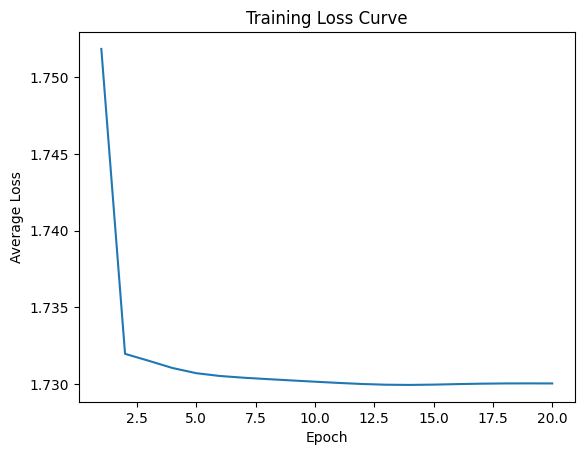

In [66]:
plt.plot(range(1, len(losses)+1), losses)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Curve")
plt.show()


In [19]:
model = TicTacToeTransformer()
model.load_state_dict(torch.load('tictactoe_transformer_model.pth'))
model.eval()
def predict_move(model, board):
    indices = torch.tensor([TOKEN_TO_IDX[s] for s in board])
    
    model.eval()
    with torch.no_grad():
        logits,weights = model(indices)
    # mask illegal moves (non-empty cells)
    for i, cell in enumerate(board):
        if cell != "_":
            logits[i] = float('-inf')

    move = torch.argmax(logits).item()
    return move



In [9]:
# O about to win - model should block at position 2
board = ["O", "O", "_", "X", "X", "_", "_", "_", "_"]
print(predict_move(model, board))  # should return 2 or 5

# X about to win - model should play position 2
board = ["X", "X", "_", "O", "O", "_", "_", "_", "_"]
print(predict_move(model, board))  # should return 2

tensor(-5.6651)
tensor(-5.9143)
tensor(7.4805)
tensor(-4.8916)
tensor(-4.4240)
tensor(7.3588)
tensor(7.3959)
tensor(7.4240)
tensor(7.3947)
2
tensor(-5.6974)
tensor(-5.9552)
tensor(7.4805)
tensor(-4.8837)
tensor(-4.4008)
tensor(7.3588)
tensor(7.3959)
tensor(7.4240)
tensor(7.3947)
2


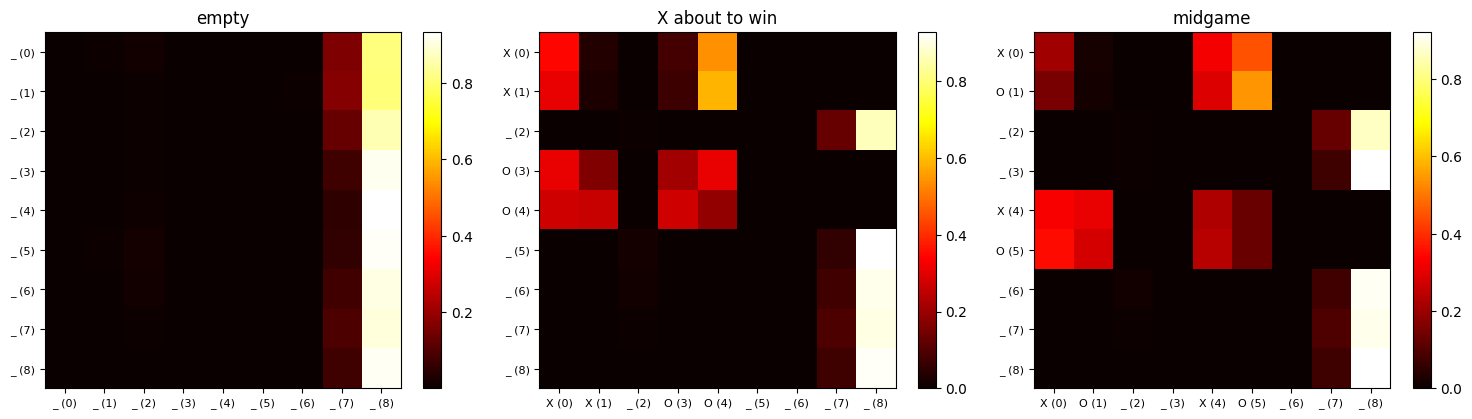

In [73]:
boards = {
    "empty": ["_", "_", "_", "_", "_", "_", "_", "_", "_"],
    "X about to win": ["X", "X", "_", "O", "O", "_", "_", "_", "_"],
    "midgame": ["X", "O", "_", "_", "X", "O", "_", "_", "_"],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, board) in zip(axes, boards.items()):
    indices = torch.tensor([TOKEN_TO_IDX[s] for s in board])
    model.eval()
    with torch.no_grad():
        logits, weights = model(indices)
    
    weight_matrix = weights
    cell_labels = [f"{s} ({i})"for i,s in enumerate(board)]
    
    im = ax.imshow(weight_matrix, cmap="hot")
    ax.set_xticks(range(9))
    ax.set_yticks(range(9))
    ax.set_xticklabels(cell_labels, fontsize=8)
    ax.set_yticklabels(cell_labels, fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [72]:
import random
from data_generation_script.uct_mcts  import MCTSNode
from data_generation_script.tic_tac_toe import Tictactoe
from copy import deepcopy


mcts_agent = game.O
ai_agent = game.X

print(f"mcts_agent: {mcts_agent} and ai_agent:{ai_agent}")
results = {'X':0,'O':0,'draw':0}
for _ in range(100):
    game = Tictactoe()
    while not game.is_gameover():
        if game.turn == ai_agent:
            move = predict_move(model,game.board)
            game.make_move(move)
        else:
            root = MCTSNode(state=game)
            mcts_best_move = root.best_action(simulations_number=500)
            #print("===mcts best move===", mcts_best_move)
            game.make_move(mcts_best_move)
    
    
    #print("\n\nFinal Board:")
    #game.print_board()
    
    
    if game.winner == game.X:
        results['X']+=1
        #print("X won!")
    elif game.winner == game.O:
        results['O']+=1
        #print("O won!")
    else:
        results['draw']+=1
        #print("Draw!")

mcts_agent: O and ai_agent:X


In [73]:
print(f"mcts_agent: {mcts_agent} and ai_agent:{ai_agent}")
results

mcts_agent: O and ai_agent:X


{'X': 91, 'O': 9, 'draw': 0}

In [ ]:
torch.save(model.state_dict(),'tictactoe_transformer_model.pth')